In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/ToyotaCorolla_-_MLR[1].csv')
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [6]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [8]:
df.shape

(1436, 11)

In [9]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [10]:
df.duplicated().sum()

np.int64(1)

In [15]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


<Axes: >

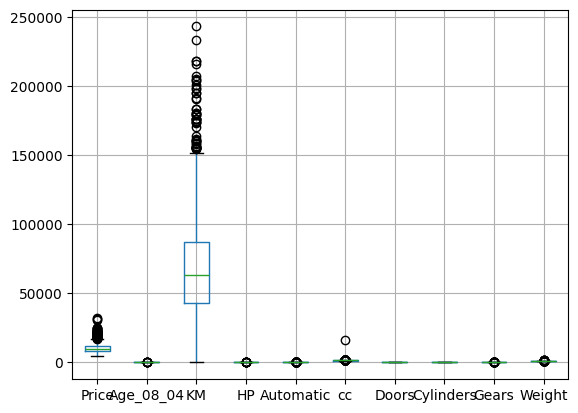

In [12]:
df.boxplot()

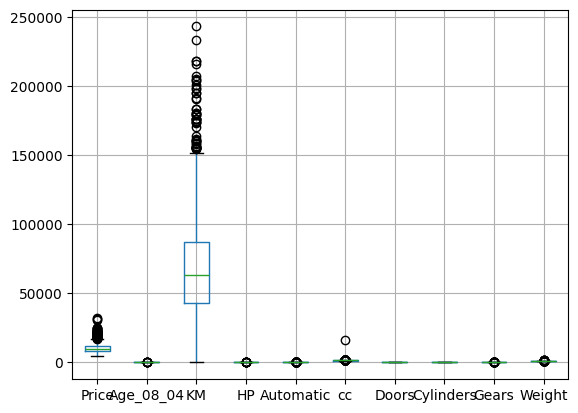

In [13]:
#Checking outliers
df.boxplot()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

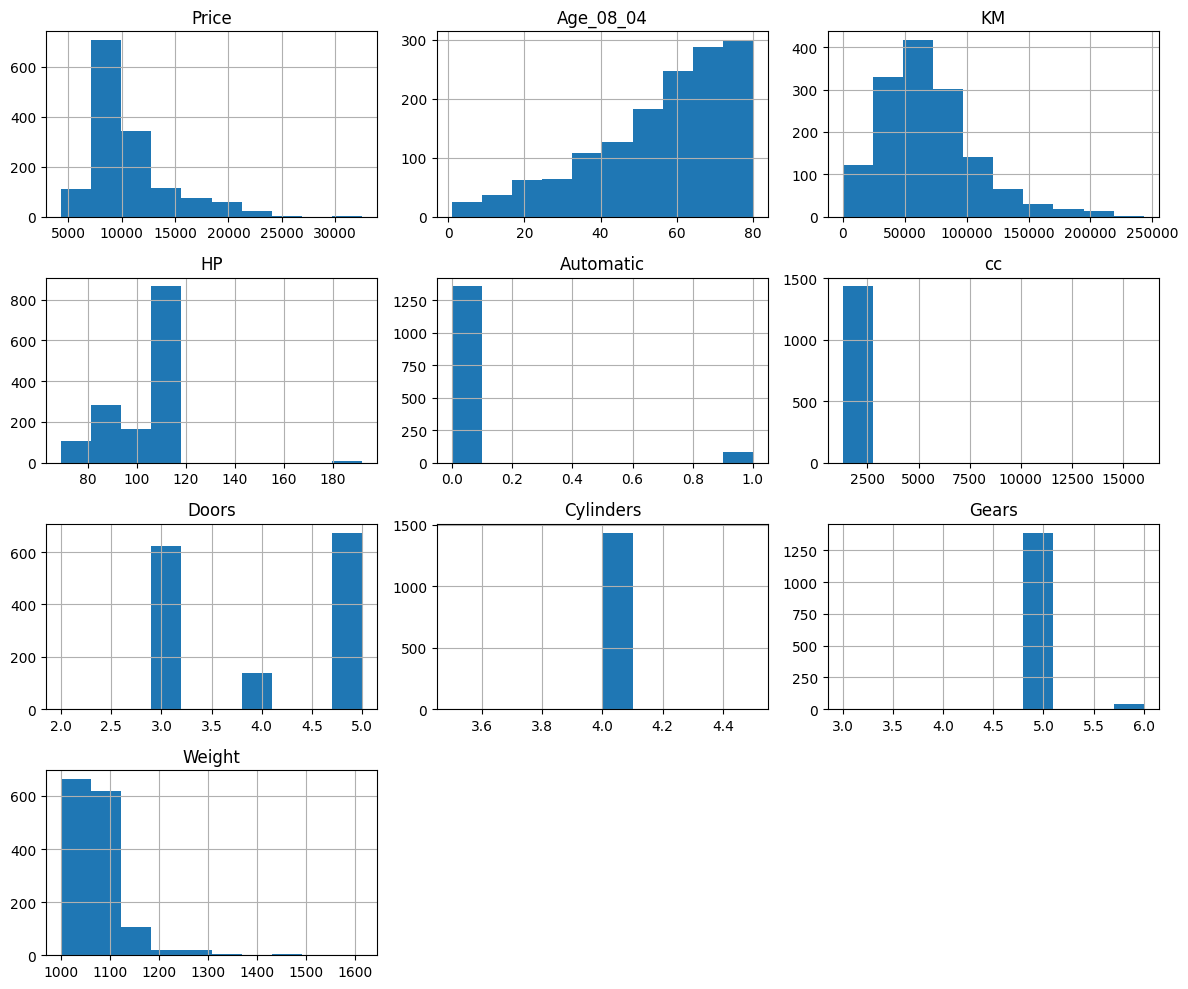

In [19]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

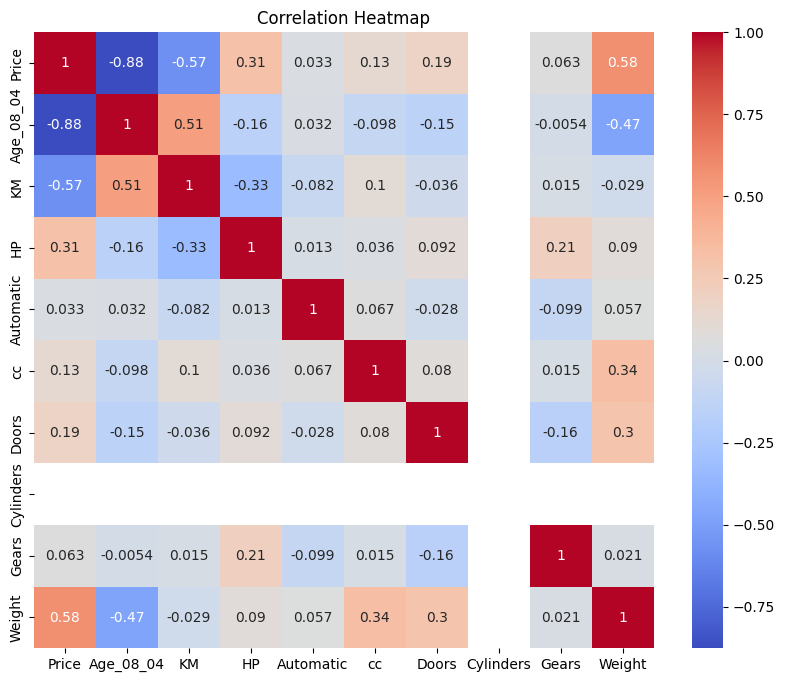

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

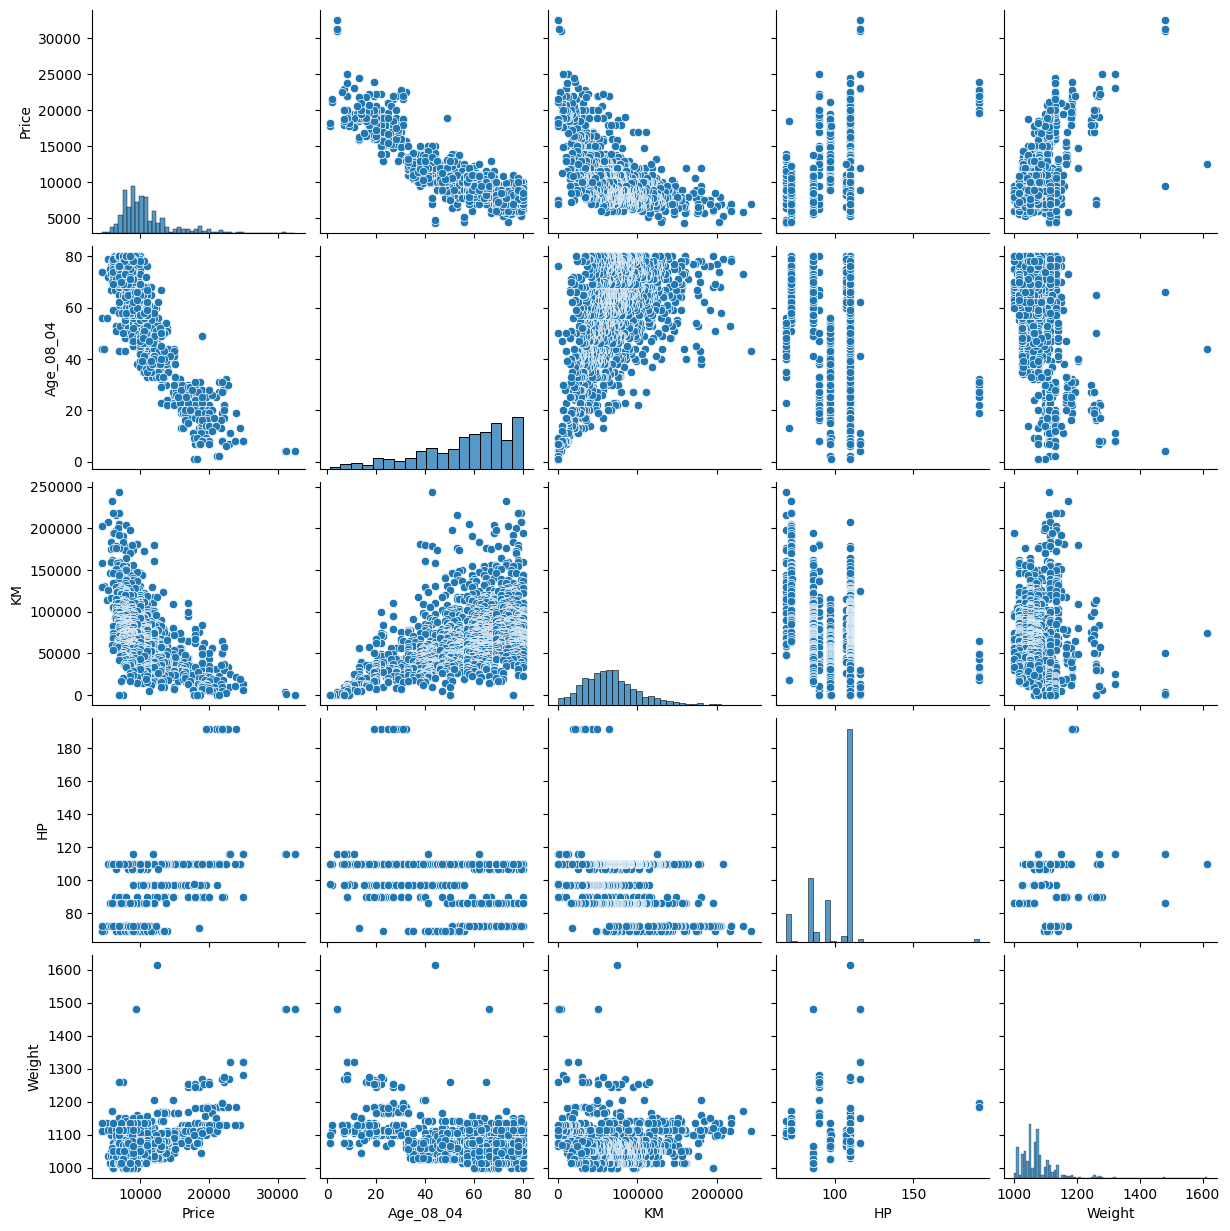

In [24]:
sns.pairplot(df[['Price','Age_08_04','KM','HP','Weight']])
plt.show()

In [27]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [28]:
X = df.drop('Price', axis=1)
y = df['Price']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)

y_pred1 = model1.predict(X_test_scaled)
# Coefficient
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
})
print(coef_df)

             Feature   Coefficient
0          Age_08_04 -2.267295e+03
1                 KM -6.116544e+02
2                 HP  2.083499e+02
3          Automatic  3.439713e+01
4                 cc -1.416192e+01
5              Doors -5.746780e+01
6          Cylinders  7.815970e-14
7              Gears  1.093404e+02
8             Weight  1.316818e+03
9   Fuel_Type_Diesel -2.172217e+01
10  Fuel_Type_Petrol  4.580477e+02


In [36]:
features2 = ['Age_08_04', 'KM', 'HP', 'Weight']
X2 = df[features2]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)
model2 = LinearRegression()
model2.fit(X2_train_s, y2_train)
y_pred2 = model2.predict(X2_test_s)

In [39]:
features3 = ['Age_08_04', 'KM', 'Weight']
X3 = df[features3]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.2, random_state=42)

scaler3 = StandardScaler()
X3_train_s = scaler3.fit_transform(X3_train)
X3_test_s = scaler3.transform(X3_test)

model3 = LinearRegression()
model3.fit(X3_train_s, y3_train)

y_pred3 = model3.predict(X3_test_s)

In [41]:
def evaluate(y_true, y_pred, model_name):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  print(f'--- {model_name} ---')
  print('MAE :', round(mae,2))
  print('RMSE:', round(rmse,2))
  print('R2 :', round(r2,4))
  print()

evaluate(y_test, y_pred1, 'Model 1')
evaluate(y2_test, y_pred2, 'Model 2')
evaluate(y3_test, y_pred3, 'Model 3')

--- Model 1 ---
MAE : 990.89
RMSE: 1484.27
R2 : 0.8349

--- Model 2 ---
MAE : 1001.2
RMSE: 1411.85
R2 : 0.8506

--- Model 3 ---
MAE : 1020.59
RMSE: 1494.98
R2 : 0.8325



In [44]:
#Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

evaluate(y_test, lasso_pred, 'Lasso')
#Lasso Coefficients
lasso_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})
print(lasso_coef)

--- Lasso ---
MAE : 990.9
RMSE: 1484.16
R2 : 0.8349

             Feature  Coefficient
0          Age_08_04 -2267.270353
1                 KM  -611.710485
2                 HP   208.460180
3          Automatic    34.335631
4                 cc   -14.044285
5              Doors   -57.288237
6          Cylinders     0.000000
7              Gears   109.268038
8             Weight  1316.405210
9   Fuel_Type_Diesel   -21.484319
10  Fuel_Type_Petrol   457.891241


In [47]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
evaluate(y_test, ridge_pred, 'Ridge')

--- Ridge ---
MAE : 990.86
RMSE: 1483.56
R2 : 0.835



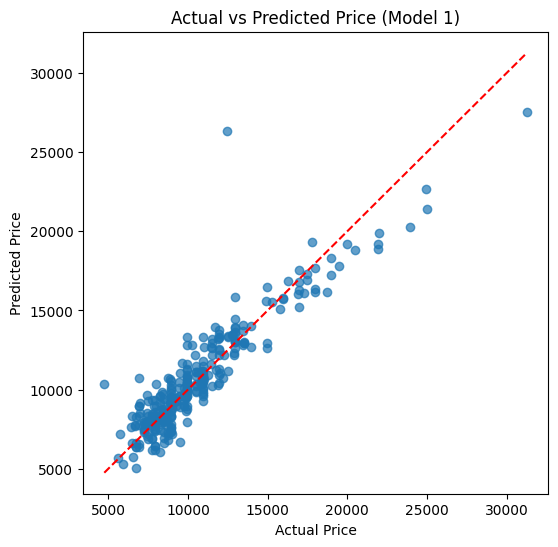

In [48]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred1, alpha=0.7)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Model 1)')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.show()